# Electronic Waste Detection and Classification
## Dataset Analysis and Preparation

This notebook analyzes the Balanced E-Waste Dataset v3 used for training the object detection model.

The analysis covers:
- Dataset structure
- Train, validation, and test splits
- Class distribution
- Image statistics
- Bounding-box annotations
- Dataset quality checks
- Sample annotation visualization

In [2]:
import sys

print("Python executable:")
print(sys.executable)

%pip install pandas matplotlib

Python executable:
c:\Users\USER\Desktop\computer vision\.venv\Scripts\python.exe
  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl (240 kB)
Using cach


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


Define project paths



In [4]:
from pathlib import Path

# Current notebook location
NOTEBOOK_DIR = Path.cwd()

# Project root
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Dataset paths
DATASET_DIR = PROJECT_ROOT / "data" / "dataset"

TRAIN_DIR = DATASET_DIR / "train"
VALID_DIR = DATASET_DIR / "valid"
TEST_DIR = DATASET_DIR / "test"

# Annotation files
TRAIN_CSV = TRAIN_DIR / "_annotations.csv"
VALID_CSV = VALID_DIR / "_annotations.csv"
TEST_CSV = TEST_DIR / "_annotations.csv"

print("Project root:")
print(PROJECT_ROOT)

print("\nDataset directory:")
print(DATASET_DIR)

print("\nTrain directory:")
print(TRAIN_DIR)

print("\nValidation directory:")
print(VALID_DIR)

print("\nTest directory:")
print(TEST_DIR)

Project root:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-

Dataset directory:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset

Train directory:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\train

Validation directory:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\valid

Test directory:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\test


## Verify dataset structure

In [5]:
# Verify required dataset directories

required_directories = {
    "Dataset": DATASET_DIR,
    "Train": TRAIN_DIR,
    "Validation": VALID_DIR,
    "Test": TEST_DIR
}

print("Directory verification:\n")

for name, path in required_directories.items():
    print(f"{name:12} : {'FOUND' if path.exists() else 'MISSING'}")
    print(f"             {path}")

print("\nAnnotation file verification:\n")

annotation_files = {
    "Train": TRAIN_CSV,
    "Validation": VALID_CSV,
    "Test": TEST_CSV
}

for name, path in annotation_files.items():
    print(f"{name:12} : {'FOUND' if path.exists() else 'MISSING'}")
    print(f"             {path}")

Directory verification:

Dataset      : FOUND
             c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset
Train        : FOUND
             c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\train
Validation   : FOUND
             c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\valid
Test         : FOUND
             c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\test

Annotation file verification:

Train        : FOUND
             c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\train\_annotations.csv
Validation   : FOUND
             c:\Users\USER\Desktop\computer vision\electronic-waste

## Load all annotations

In [6]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Dataset loaded successfully.")

print("\nTrain annotations:", len(train_df))
print("Validation annotations:", len(valid_df))
print("Test annotations:", len(test_df))

Dataset loaded successfully.

Train annotations: 5590
Validation annotations: 1641
Test annotations: 869


## Inspect annotation structure

In [7]:
print("Column names:")
print(train_df.columns.tolist())

print("\nData types:")
print(train_df.dtypes)

print("\nFirst 5 annotations:")
display(train_df.head())

print("\nMissing values:")
print(train_df.isnull().sum())

Column names:
['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

Data types:
filename      str
width       int64
height      int64
class         str
xmin        int64
ymin        int64
xmax        int64
ymax        int64
dtype: object

First 5 annotations:


,filename,width,height,class,xmin,ymin,xmax,ymax
0,000000299923_jpg.rf.33767390e161f2fccabd637c60...,640,640,Refrigerator,138,180,521,510
1,top-view-of-green-usb-flash-drive_jpg.rf.33a34...,640,640,USB-Flash-Drive,70,256,531,388
2,31_jpg.rf.338727c75867e7ad93a98455f9869a45.jpg,640,640,Computer-Mouse,62,106,624,501
3,4-removebg-preview_png.rf.338d37e4900b878a710a...,640,640,Battery,275,158,363,482
4,IMG_20220622_101442_jpg.rf.33ecc8eac59bee05dac...,640,640,Straight-Tube-Fluorescent-Lamp,297,120,365,489



Missing values:
filename    0
width       0
height      0
class       0
xmin        0
ymin        0
xmax        0
ymax        0
dtype: int64


## Dataset split statistics

In [8]:
def split_statistics(df, split_name):
    return {
        "Split": split_name,
        "Annotation Rows": len(df),
        "Unique Images": df["filename"].nunique(),
        "Classes": df["class"].nunique(),
        "Objects per Image": len(df) / df["filename"].nunique()
    }


split_stats = pd.DataFrame([
    split_statistics(train_df, "Train"),
    split_statistics(valid_df, "Validation"),
    split_statistics(test_df, "Test")
])

display(split_stats)

,Split,Annotation Rows,Unique Images,Classes,Objects per Image
0,Train,5590,4991,37,1.120016
1,Validation,1641,1444,37,1.136427
2,Test,869,776,37,1.119845


In [9]:
total_images = split_stats["Unique Images"].sum()
total_objects = split_stats["Annotation Rows"].sum()

print(f"Total images: {total_images:,}")
print(f"Total annotated objects: {total_objects:,}")
print(f"Total classes: {train_df['class'].nunique()}")

Total images: 7,211
Total annotated objects: 8,100
Total classes: 37


## Calculate split percentages

In [10]:
split_stats["Image Percentage"] = (
    split_stats["Unique Images"] / split_stats["Unique Images"].sum() * 100
)

display(
    split_stats[
        ["Split", "Unique Images", "Annotation Rows", "Classes", "Image Percentage"]
    ].round(2)
)

,Split,Unique Images,Annotation Rows,Classes,Image Percentage
0,Train,4991,5590,37,69.21
1,Validation,1444,1641,37,20.02
2,Test,776,869,37,10.76


## Create the class mapping

In [11]:
classes = sorted(train_df["class"].unique())

class_mapping = pd.DataFrame({
    "class_id": range(len(classes)),
    "class_name": classes
})

print("Number of classes:", len(classes))

display(class_mapping)

Number of classes: 37


,class_id,class_name
0,0,Battery
1,1,Blood-Pressure-Monitor
2,2,Boiler
3,3,Clothes-Iron
4,4,Coffee-Machine
5,5,Computer-Keyboard
6,6,Computer-Mouse
7,7,Cooling-Display
8,8,Desktop-PC
9,9,Digital-Oscilloscope


## Verify class consistency

In [12]:
train_classes = set(train_df["class"].unique())
valid_classes = set(valid_df["class"].unique())
test_classes = set(test_df["class"].unique())

print("Train classes:", len(train_classes))
print("Validation classes:", len(valid_classes))
print("Test classes:", len(test_classes))

print("\nTrain = Validation:", train_classes == valid_classes)
print("Train = Test:", train_classes == test_classes)

print("\nClasses missing from Validation:")
print(sorted(train_classes - valid_classes))

print("\nClasses missing from Test:")
print(sorted(train_classes - test_classes))

Train classes: 37
Validation classes: 37
Test classes: 37

Train = Validation: True
Train = Test: True

Classes missing from Validation:
[]

Classes missing from Test:
[]


## Class distribution

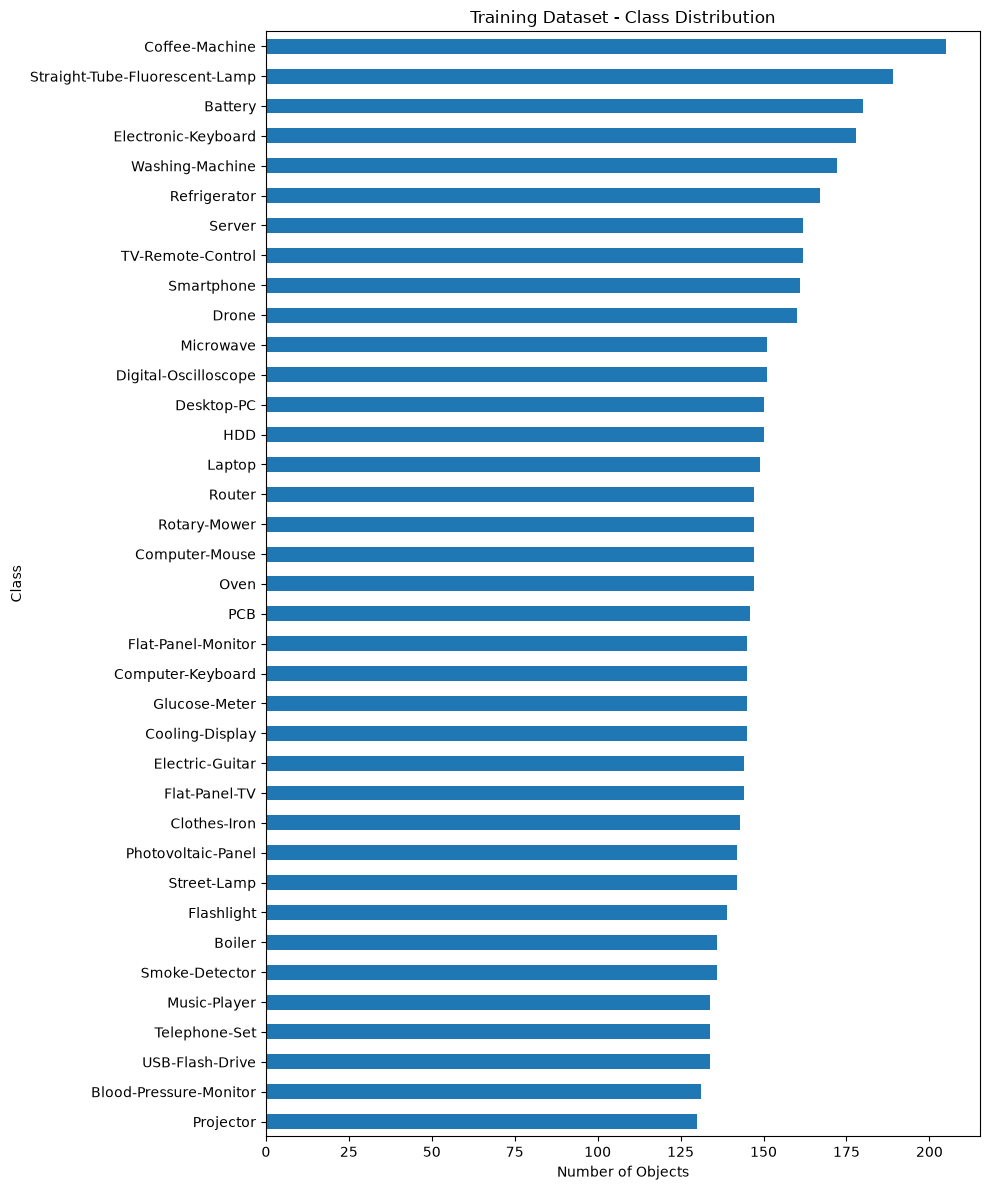

In [13]:
train_class_counts = train_df["class"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 12))
train_class_counts.plot(kind="barh")

plt.title("Training Dataset - Class Distribution")
plt.xlabel("Number of Objects")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

## Class distribution across all splits

In [14]:
train_counts = train_df["class"].value_counts()
valid_counts = valid_df["class"].value_counts()
test_counts = test_df["class"].value_counts()

class_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": valid_counts,
    "Test": test_counts
}).fillna(0).astype(int)

display(class_distribution)

,Train,Validation,Test
class,,,
Battery,180,37,33
Blood-Pressure-Monitor,131,52,19
Boiler,136,43,30
Clothes-Iron,143,47,20
Coffee-Machine,205,50,33
Computer-Keyboard,145,40,22
Computer-Mouse,147,36,20
Cooling-Display,145,42,20
Desktop-PC,150,37,19


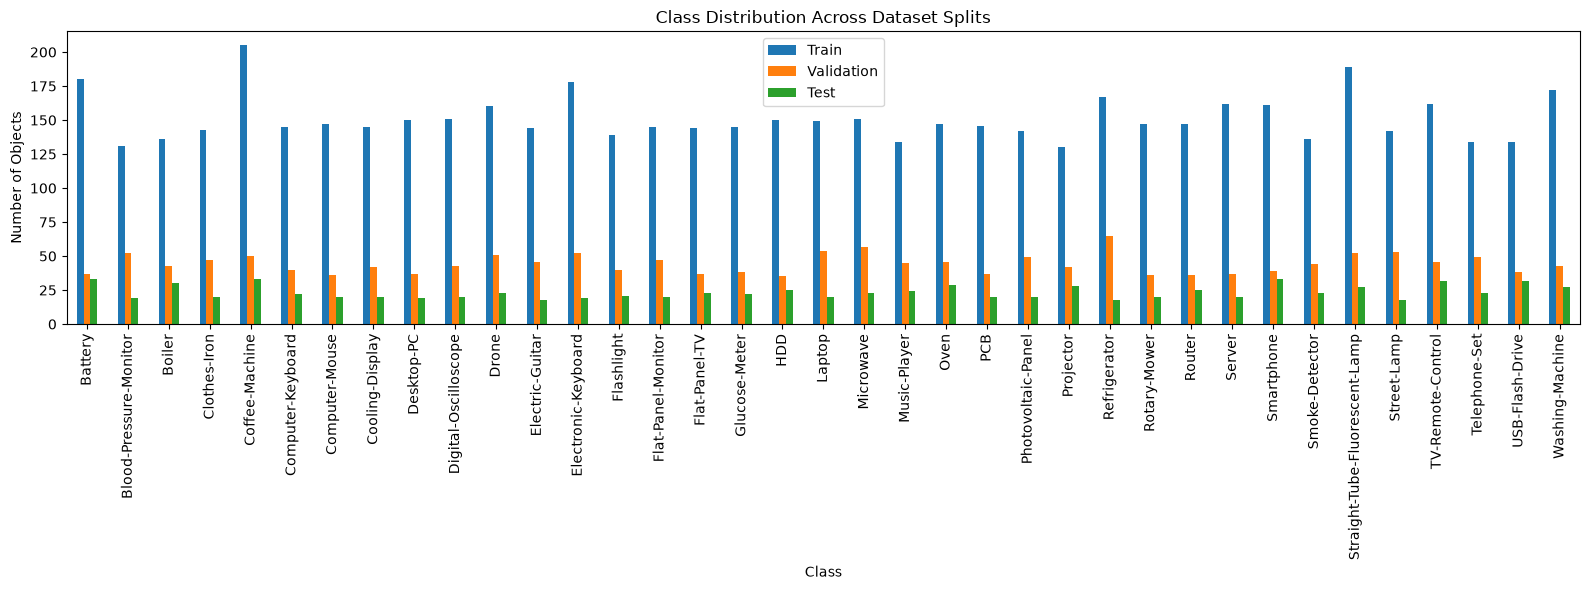

In [15]:
class_distribution.plot(
    kind="bar",
    figsize=(16, 6)
)

plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Verify image files

In [16]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_image_files(directory):
    return [
        path for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]


train_images = get_image_files(TRAIN_DIR)
valid_images = get_image_files(VALID_DIR)
test_images = get_image_files(TEST_DIR)

print("Physical image files:")
print("Train:", len(train_images))
print("Validation:", len(valid_images))
print("Test:", len(test_images))

print("\nUnique annotated image filenames:")
print("Train:", train_df["filename"].nunique())
print("Validation:", valid_df["filename"].nunique())
print("Test:", test_df["filename"].nunique())

Physical image files:
Train: 4990
Validation: 1444
Test: 776

Unique annotated image filenames:
Train: 4991
Validation: 1444
Test: 776


## Find missing annotation images

In [17]:
def check_missing_images(df, image_files):
    actual_names = {p.name for p in image_files}
    annotated_names = set(df["filename"])

    missing = sorted(annotated_names - actual_names)
    return missing


missing_train = check_missing_images(train_df, train_images)
missing_valid = check_missing_images(valid_df, valid_images)
missing_test = check_missing_images(test_df, test_images)

print("Missing physical images referenced by annotations:")
print("Train:", len(missing_train))
print("Validation:", len(missing_valid))
print("Test:", len(missing_test))

Missing physical images referenced by annotations:
Train: 1
Validation: 0
Test: 0


## Find images without annotations

In [18]:
def check_unannotated_images(df, image_files):
    annotated_names = set(df["filename"])
    actual_names = {p.name for p in image_files}

    unannotated = sorted(actual_names - annotated_names)
    return unannotated


unannotated_train = check_unannotated_images(train_df, train_images)
unannotated_valid = check_unannotated_images(valid_df, valid_images)
unannotated_test = check_unannotated_images(test_df, test_images)

print("Images without annotation entries:")
print("Train:", len(unannotated_train))
print("Validation:", len(unannotated_valid))
print("Test:", len(unannotated_test))

Images without annotation entries:
Train: 0
Validation: 0
Test: 0


## Check duplicate annotation rows

In [20]:
for name, df in [
    ("Train", train_df),
    ("Validation", valid_df),
    ("Test", test_df)
]:
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate annotation rows")

Train: 0 duplicate annotation rows
Validation: 1 duplicate annotation rows
Test: 0 duplicate annotation rows


## Validate bounding boxes

In [21]:
def bounding_box_quality_check(df, split_name):
    invalid_x = (df["xmin"] < 0) | (df["xmax"] > df["width"]) | (df["xmin"] >= df["xmax"])
    invalid_y = (df["ymin"] < 0) | (df["ymax"] > df["height"]) | (df["ymin"] >= df["ymax"])

    invalid = invalid_x | invalid_y

    print(f"\n===== {split_name} =====")
    print("Total annotations:", len(df))
    print("Invalid bounding boxes:", invalid.sum())
    
    if invalid.sum() > 0:
        display(df[invalid].head(20))


bounding_box_quality_check(train_df, "Train")
bounding_box_quality_check(valid_df, "Validation")
bounding_box_quality_check(test_df, "Test")


===== Train =====
Total annotations: 5590
Invalid bounding boxes: 0

===== Validation =====
Total annotations: 1641
Invalid bounding boxes: 0

===== Test =====
Total annotations: 869
Invalid bounding boxes: 0


## Bounding-box statistics

In [22]:
def add_bbox_features(df):
    df = df.copy()

    df["bbox_width"] = df["xmax"] - df["xmin"]
    df["bbox_height"] = df["ymax"] - df["ymin"]

    df["bbox_area"] = df["bbox_width"] * df["bbox_height"]

    df["bbox_area_ratio"] = (
        df["bbox_area"] / (df["width"] * df["height"])
    )

    df["bbox_aspect_ratio"] = (
        df["bbox_width"] / df["bbox_height"]
    )

    return df


train_df = add_bbox_features(train_df)
valid_df = add_bbox_features(valid_df)
test_df = add_bbox_features(test_df)

display(
    train_df[
        [
            "class",
            "bbox_width",
            "bbox_height",
            "bbox_area",
            "bbox_area_ratio",
            "bbox_aspect_ratio"
        ]
    ].head()
)

,class,bbox_width,bbox_height,bbox_area,bbox_area_ratio,bbox_aspect_ratio
0,Refrigerator,383,330,126390,0.308569,1.160606
1,USB-Flash-Drive,461,132,60852,0.148564,3.492424
2,Computer-Mouse,562,395,221990,0.541968,1.422785
3,Battery,88,324,28512,0.069609,0.271605
4,Straight-Tube-Fluorescent-Lamp,68,369,25092,0.061260,0.184282


## Bounding-box statistics summary

In [23]:
bbox_summary = train_df[
    [
        "bbox_width",
        "bbox_height",
        "bbox_area_ratio",
        "bbox_aspect_ratio"
    ]
].describe()

display(bbox_summary)

,bbox_width,bbox_height,bbox_area_ratio,bbox_aspect_ratio
count,5590.000000,5590.000000,5590.000000,5590.000000
mean,353.832558,359.033095,0.331701,1.212482
std,174.296651,167.518763,0.232403,0.964659
min,5.000000,4.000000,0.000103,0.074627
25%,207.000000,227.250000,0.146225,0.639662
50%,346.000000,354.000000,0.295332,1.015335
75%,503.000000,494.000000,0.476544,1.487277
max,640.000000,640.000000,1.000000,19.103448


## Objects per image

In [24]:
objects_per_image = (
    train_df
    .groupby("filename")
    .size()
    .value_counts()
    .sort_index()
)

display(
    objects_per_image.rename("Number of Images").to_frame()
)

,Number of Images
1,4596
2,282
3,67
4,28
5,9
6,4
8,2
9,1
10,1
13,1


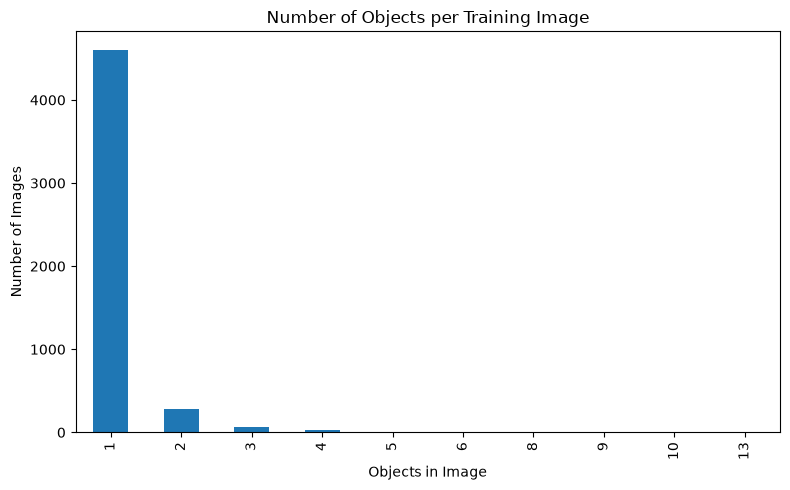

In [26]:
plt.figure(figsize=(8, 5))

objects_per_image.sort_index().plot(kind="bar")

plt.title("Number of Objects per Training Image")
plt.xlabel("Objects in Image")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

## Image dimensions

In [27]:
def inspect_image_dimensions(image_files, sample_limit=None):
    records = []

    files = image_files if sample_limit is None else image_files[:sample_limit]

    for image_path in files:
        try:
            with Image.open(image_path) as img:
                records.append({
                    "filename": image_path.name,
                    "width": img.width,
                    "height": img.height,
                    "format": img.format
                })
        except Exception as e:
            records.append({
                "filename": image_path.name,
                "width": None,
                "height": None,
                "format": f"ERROR: {e}"
            })

    return pd.DataFrame(records)


train_image_info = inspect_image_dimensions(train_images)

display(train_image_info.head())

print("\nImage dimensions:")
display(
    train_image_info.groupby(["width", "height"]).size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

,filename,width,height,format
0,-1-_jpg.rf.7a032a885379e65b1644b607cd9a868a.jpg,640,640,JPEG
1,-1-_jpg.rf.c13a1c80673fd68958f6ea048134d768.jpg,640,640,JPEG
2,-2-_jpg.rf.144140e3959c9900b13e3fea28431c64.jpg,640,640,JPEG
3,-3-_jpg.rf.ca36888c7a981ab2f4c7728fc9a81a45.jpg,640,640,JPEG
4,-PHILIPS-DST501010-1-_jpeg.rf.2aa29dbefe0d5139...,640,640,JPEG



Image dimensions:


,width,height,count
0,640,640,4990


## Check annotation/image dimension consistency

In [28]:
dimension_check = train_df[
    ["filename", "width", "height"]
].drop_duplicates()

merged_dimensions = dimension_check.merge(
    train_image_info[["filename", "width", "height"]],
    on="filename",
    suffixes=("_annotation", "_actual")
)

merged_dimensions["width_match"] = (
    merged_dimensions["width_annotation"]
    == merged_dimensions["width_actual"]
)

merged_dimensions["height_match"] = (
    merged_dimensions["height_annotation"]
    == merged_dimensions["height_actual"]
)

print(
    "Width mismatches:",
    (~merged_dimensions["width_match"]).sum()
)

print(
    "Height mismatches:",
    (~merged_dimensions["height_match"]).sum()
)

Width mismatches: 0
Height mismatches: 0


## Visualize bounding-box annotations

In [29]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def show_annotated_image(df, image_dir, image_index=0):
    filenames = df["filename"].unique()

    filename = filenames[image_index]

    image_path = image_dir / filename

    image = Image.open(image_path).convert("RGB")

    image_annotations = df[df["filename"] == filename]

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.imshow(image)

    for _, row in image_annotations.iterrows():
        x = row["xmin"]
        y = row["ymin"]
        width = row["xmax"] - row["xmin"]
        height = row["ymax"] - row["ymin"]

        rectangle = patches.Rectangle(
            (x, y),
            width,
            height,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        ax.text(
            x,
            y,
            row["class"],
            fontsize=9,
            backgroundcolor="white"
        )

    ax.set_title(filename)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

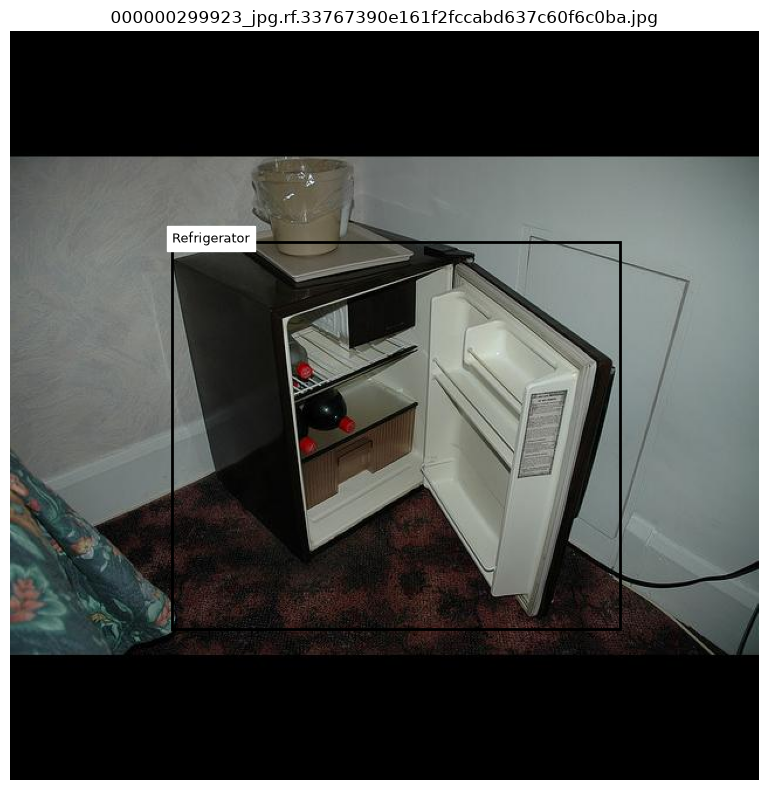

In [30]:
show_annotated_image(train_df, TRAIN_DIR, image_index=0)

## Show several annotated examples

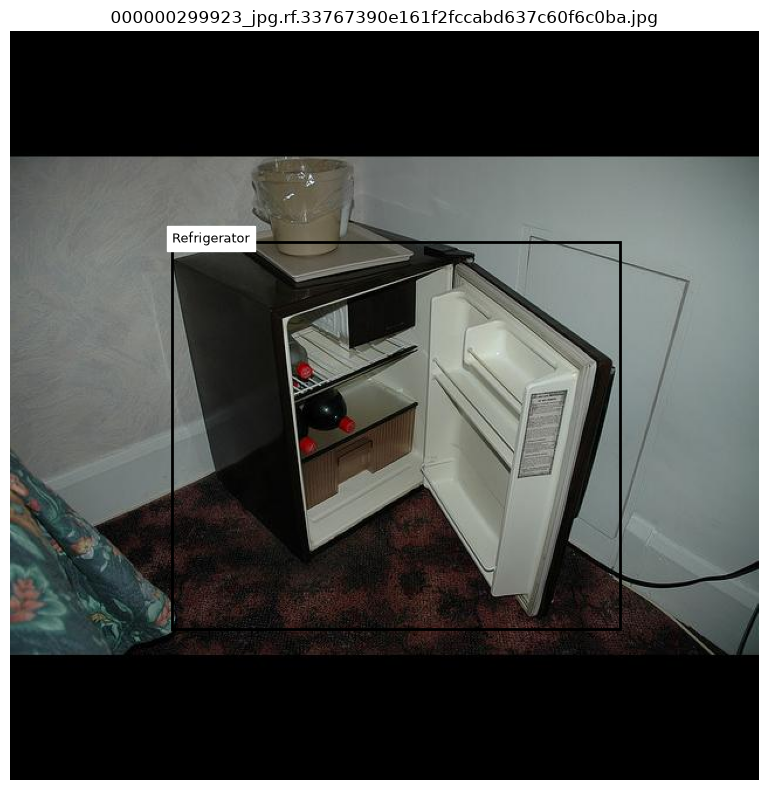

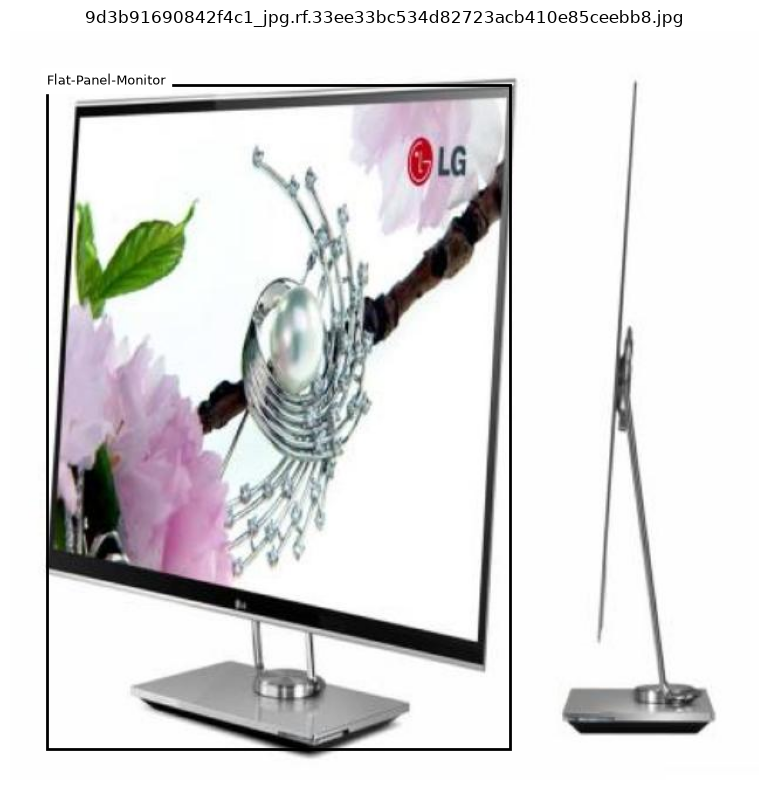

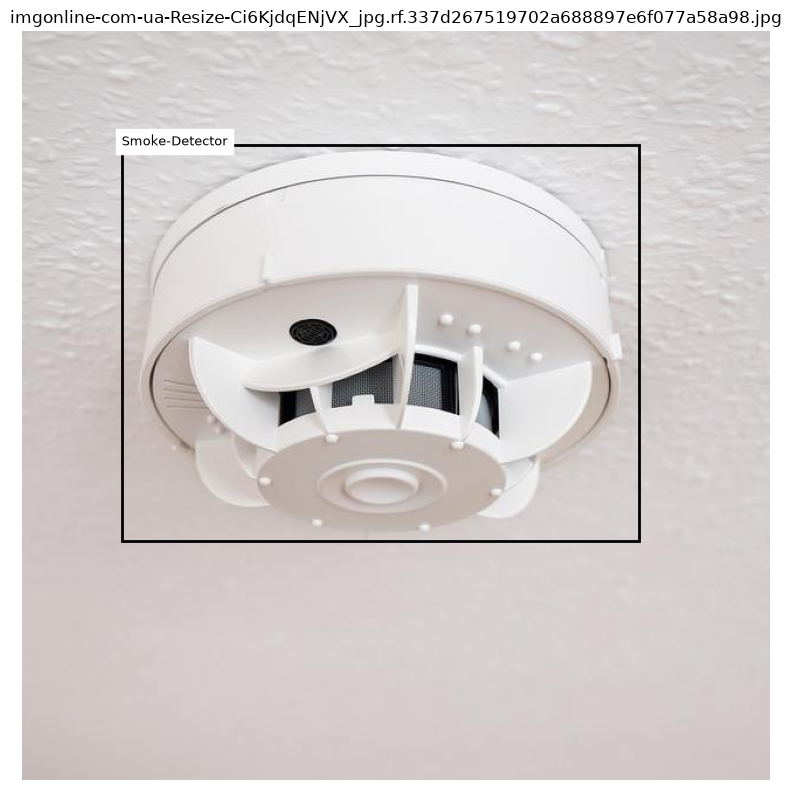

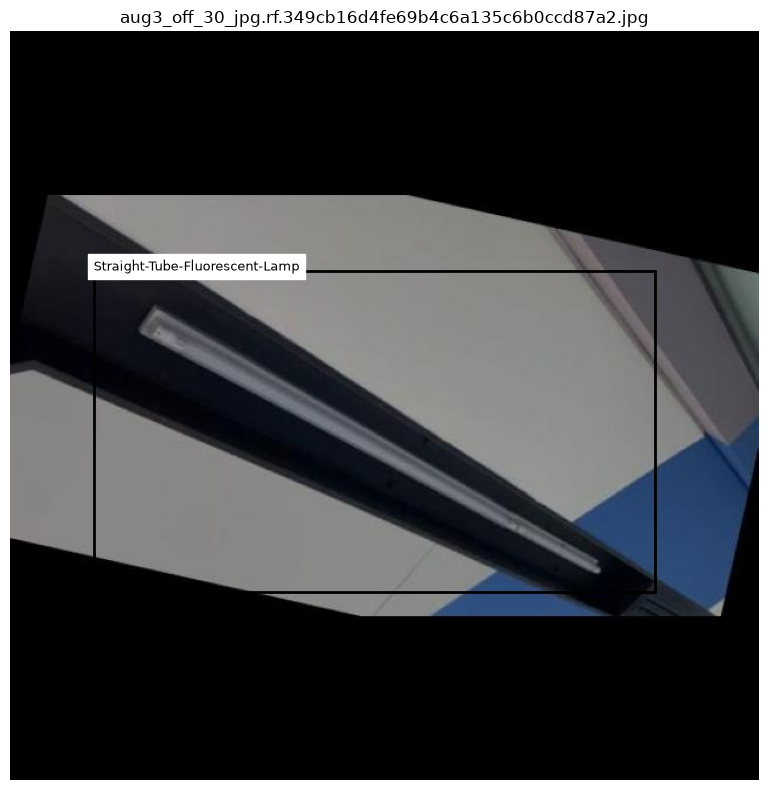

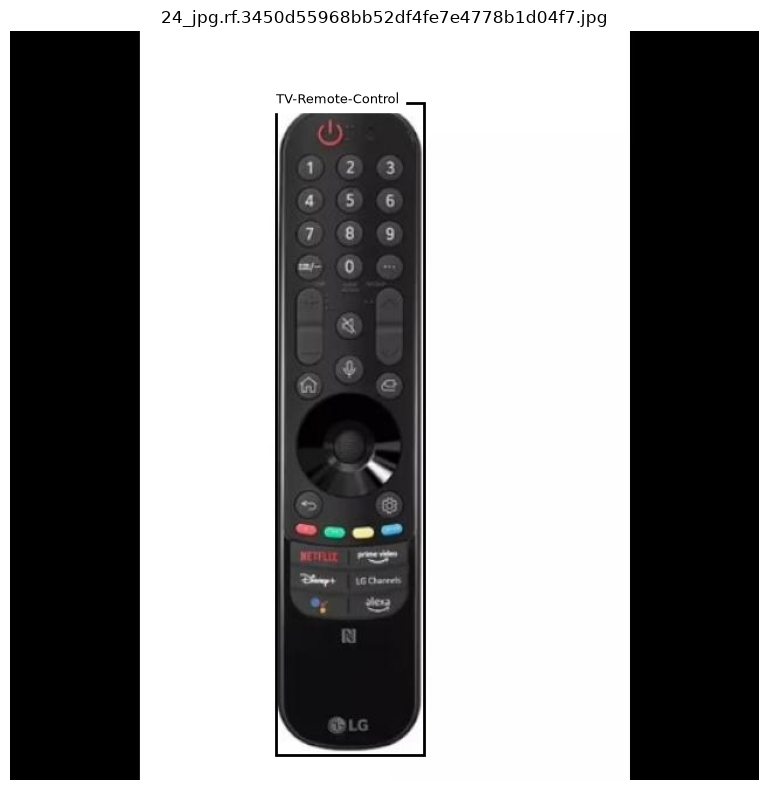

In [31]:
sample_indices = [0, 10, 20, 30, 40]

for index in sample_indices:
    show_annotated_image(
        train_df,
        TRAIN_DIR,
        image_index=index
    )

## Final dataset quality summary

In [32]:
print("========== DATASET QUALITY SUMMARY ==========\n")

print(f"Total images: {total_images:,}")
print(f"Total annotated objects: {total_objects:,}")
print(f"Number of classes: {len(classes)}")

print("\nSplit image counts:")
print(split_stats[["Split", "Unique Images"]].to_string(index=False))

print("\nClass consistency:")
print("Train = Validation:", train_classes == valid_classes)
print("Train = Test:", train_classes == test_classes)

print("\nMissing annotation images:")
print("Train:", len(missing_train))
print("Validation:", len(missing_valid))
print("Test:", len(missing_test))

print("\nUnannotated images:")
print("Train:", len(unannotated_train))
print("Validation:", len(unannotated_valid))
print("Test:", len(unannotated_test))

print("\nDuplicate annotation rows:")
print("Train:", train_df.duplicated().sum())
print("Validation:", valid_df.duplicated().sum())
print("Test:", test_df.duplicated().sum())

print("\nDataset analysis completed.")

========== DATASET QUALITY SUMMARY ==========

Total images: 7,211
Total annotated objects: 8,100
Number of classes: 37

Split image counts:
     Split  Unique Images
     Train           4991
Validation           1444
      Test            776

Class consistency:
Train = Validation: True
Train = Test: True

Missing annotation images:
Train: 1
Validation: 0
Test: 0

Unannotated images:
Train: 0
Validation: 0
Test: 0

Duplicate annotation rows:
Train: 0
Validation: 1
Test: 0

Dataset analysis completed.


In [37]:
# Identify annotation filenames whose image files are missing

def find_missing_annotation_images(df, image_dir):
    actual_image_names = {
        path.name
        for path in image_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    }

    annotated_image_names = set(df["filename"])

    missing_names = sorted(
        annotated_image_names - actual_image_names
    )

    return missing_names


missing_train_names = find_missing_annotation_images(
    train_df,
    TRAIN_DIR
)

print("Missing training image(s):")
for filename in missing_train_names:
    print(filename)

print("\nNumber of missing training images:", len(missing_train_names))

Missing training image(s):
asus-ax6000-wifi-6-gaming-router-rt-ax88u-dual-band-gigabit-wireless-router-8-gb-ports-gaming-streaming-aimesh-compatible-included-lifetime-019c00bf4f2e4efcb694aadb55131da9_jpeg.rf.2afb1fc41b5585a0dd70c1ee17921e45.jpg

Number of missing training images: 1


In [38]:
# Inspect annotation records associated with missing training images

missing_train_annotations = train_df[
    train_df["filename"].isin(missing_train_names)
]

print("Number of annotation records for missing image(s):",
      len(missing_train_annotations))

display(missing_train_annotations)

Number of annotation records for missing image(s): 1


,filename,width,height,class,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,bbox_area_ratio,bbox_aspect_ratio
2855,asus-ax6000-wifi-6-gaming-router-rt-ax88u-dual...,640,640,Router,18,147,625,495,607,348,211236,0.515713,1.744253


In [1]:
# Effect of removing the orphan annotation

clean_train_df = train_df[
    ~train_df["filename"].isin(missing_train_names)
].copy()

print("Original training annotations:", len(train_df))
print("Cleaned training annotations:", len(clean_train_df))

print("\nOriginal unique annotated images:",
      train_df["filename"].nunique())

print("Cleaned unique annotated images:",
      clean_train_df["filename"].nunique())

print("\nRemoved annotation records:",
      len(train_df) - len(clean_train_df))

print("\nRemoved classes:")
display(
    train_df[
        train_df["filename"].isin(missing_train_names)
    ]["class"].value_counts()
)

NameError: name 'train_df' is not defined